# Distributed FinTech Time-Series Forecasting using PySpark
### Guided Lab — Apple Stock Dataset (Google Colab)

This notebook builds a distributed time-series forecasting pipeline in PySpark to predict Apple's future **Close** price.

**Pipeline stages**
1. Environment setup (install & start Spark)
2. Load data into a Spark DataFrame
3. Preprocess & sort chronologically
4. Feature engineering — lag features & rolling statistics (window functions)
5. Create the target variable (future price) & convert to supervised learning format
6. Time-based train/test split (no data leakage)
7. Train distributed regression models — Linear Regression & Gradient Boosted Trees
8. Evaluate with RMSE / MAE
9. Visualise actual vs predicted values


In [1]:
!pip install -q pyspark

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import matplotlib.pyplot as plt

spark = (
    SparkSession.builder
    .appName("AppleStockForecasting")
    .master("local[*]")
    .getOrCreate()
)

spark


In [3]:
# Option A: Upload directly in Colab
from google.colab import files
uploaded = files.upload()  # select aapl_stock_data.csv when prompted


Saving aapl_stock_data.csv to aapl_stock_data.csv


In [4]:
DATA_PATH = "aapl_stock_data.csv"

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

df.printSchema()
df.show(5)
print("Row count:", df.count())


root
 |-- Date: date (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- PERatio: double (nullable = true)
 |-- EPS: double (nullable = true)
 |-- MarketCap: long (nullable = true)

+----------+-----+-----+-----+-----+-------+-------+----+-------------+
|      Date| Open| High|  Low|Close| Volume|PERatio| EPS|    MarketCap|
+----------+-----+-----+-----+-----+-------+-------+----+-------------+
|1999-11-01| 80.0|80.69|77.37|77.62|2487300|  35.85|6.43|3535123251000|
|1999-11-02| 78.0|81.69|77.31|80.25|3564600|  35.85|6.43|3535123251000|
|1999-11-03|81.62|83.25| 81.0| 81.5|2932700|  35.85|6.43|3535123251000|
|1999-11-04|82.06|85.37|80.62|83.62|3384700|  35.85|6.43|3535123251000|
|1999-11-05|84.62|88.37| 84.0|88.31|3721500|  35.85|6.43|3535123251000|
+----------+-----+-----+-----+-----+-------+-------+----+-------------+
only showing top

In [5]:
df = df.withColumn("Date", F.to_date("Date"))

# Keep only the columns needed for the forecasting pipeline
cols_needed = ["Date", "Open", "High", "Low", "Close", "Volume"]
df = df.select(*cols_needed)

# Drop rows with any nulls in the key columns
df = df.dropna(subset=cols_needed)

# Sort chronologically — critical for time-series feature generation
df = df.orderBy("Date")

df.show(5)
print("Row count after cleaning:", df.count())


+----------+-----+-----+-----+-----+-------+
|      Date| Open| High|  Low|Close| Volume|
+----------+-----+-----+-----+-----+-------+
|1999-11-01| 80.0|80.69|77.37|77.62|2487300|
|1999-11-02| 78.0|81.69|77.31|80.25|3564600|
|1999-11-03|81.62|83.25| 81.0| 81.5|2932700|
|1999-11-04|82.06|85.37|80.62|83.62|3384700|
|1999-11-05|84.62|88.37| 84.0|88.31|3721500|
+----------+-----+-----+-----+-----+-------+
only showing top 5 rows
Row count after cleaning: 6213


In [6]:
# Window ordered by Date for lag features (row-based)
w = Window.orderBy("Date")

# Window for rolling statistics (trailing N rows, inclusive of current row)
w_roll5 = Window.orderBy("Date").rowsBetween(-4, 0)
w_roll10 = Window.orderBy("Date").rowsBetween(-9, 0)

df_feat = (
    df
    .withColumn("lag_1", F.lag("Close", 1).over(w))
    .withColumn("lag_2", F.lag("Close", 2).over(w))
    .withColumn("lag_3", F.lag("Close", 3).over(w))
    .withColumn("lag_5", F.lag("Close", 5).over(w))
    .withColumn("rolling_mean_5", F.avg("Close").over(w_roll5))
    .withColumn("rolling_std_5", F.stddev("Close").over(w_roll5))
    .withColumn("rolling_mean_10", F.avg("Close").over(w_roll10))
    .withColumn("rolling_std_10", F.stddev("Close").over(w_roll10))
    .withColumn("daily_return", (F.col("Close") - F.lag("Close", 1).over(w)) / F.lag("Close", 1).over(w))
)

df_feat.show(10)


+----------+-----+-----+-----+-----+-------+-----+-----+-----+-----+--------------+------------------+-----------------+------------------+--------------------+
|      Date| Open| High|  Low|Close| Volume|lag_1|lag_2|lag_3|lag_5|rolling_mean_5|     rolling_std_5|  rolling_mean_10|    rolling_std_10|        daily_return|
+----------+-----+-----+-----+-----+-------+-----+-----+-----+-----+--------------+------------------+-----------------+------------------+--------------------+
|1999-11-01| 80.0|80.69|77.37|77.62|2487300| NULL| NULL| NULL| NULL|         77.62|              NULL|            77.62|              NULL|                NULL|
|1999-11-02| 78.0|81.69|77.31|80.25|3564600|77.62| NULL| NULL| NULL|        78.935|1.8596908345206167|           78.935|1.8596908345206167|0.033883019840247296|
|1999-11-03|81.62|83.25| 81.0| 81.5|2932700|80.25|77.62| NULL| NULL|         79.79| 1.980479739861024|            79.79| 1.980479739861024| 0.01557632398753894|
|1999-11-04|82.06|85.37|80.62|83.6

In [7]:
# Target: next day's Close price (forecast horizon = 1 day ahead)
w_lead = Window.orderBy("Date")
df_supervised = df_feat.withColumn("target", F.lead("Close", 1).over(w_lead))

# Drop rows with nulls introduced by lag/rolling windows and the final row (no future target)
feature_cols = [
    "Open", "High", "Low", "Close", "Volume",
    "lag_1", "lag_2", "lag_3", "lag_5",
    "rolling_mean_5", "rolling_std_5",
    "rolling_mean_10", "rolling_std_10",
    "daily_return"
]

df_supervised = df_supervised.dropna(subset=feature_cols + ["target"])

print("Row count after feature/target engineering:", df_supervised.count())
df_supervised.select("Date", *feature_cols, "target").show(10)


Row count after feature/target engineering: 6207
+----------+-----+-----+-----+-----+-------+-----+-----+-----+-----+--------------+------------------+-----------------+------------------+--------------------+------+
|      Date| Open| High|  Low|Close| Volume|lag_1|lag_2|lag_3|lag_5|rolling_mean_5|     rolling_std_5|  rolling_mean_10|    rolling_std_10|        daily_return|target|
+----------+-----+-----+-----+-----+-------+-----+-----+-----+-----+--------------+------------------+-----------------+------------------+--------------------+------+
|1999-11-08|87.75|97.73|86.75|96.37|8490400|88.31|83.62| 81.5|77.62|         86.01| 6.554567110038619|84.61166666666666| 6.789837749656958| 0.09126939191484545| 89.62|
|1999-11-09|94.37| 94.5| 88.0|89.62|7224800|96.37|88.31|83.62|80.25|        87.884| 5.791038766922562|85.32714285714285| 6.480863405148303| -0.0700425443602781| 91.44|
|1999-11-10|88.25|93.25|88.12|91.44|5159800|89.62|96.37|88.31| 81.5|        89.872| 4.644175922593803|         

In [8]:
# Add a row index to perform a chronological split
df_indexed = df_supervised.withColumn("row_id", F.row_number().over(Window.orderBy("Date")))

total_rows = df_indexed.count()
split_point = int(total_rows * 0.8)

train_df = df_indexed.filter(F.col("row_id") <= split_point)
test_df = df_indexed.filter(F.col("row_id") > split_point)

print(f"Total rows: {total_rows}")
print(f"Train rows: {train_df.count()}  (up to {train_df.agg(F.max('Date')).first()[0]})")
print(f"Test rows:  {test_df.count()}  (from {test_df.agg(F.min('Date')).first()[0]})")


Total rows: 6207
Train rows: 4965  (up to 2019-08-02)
Test rows:  1242  (from 2019-08-05)


In [9]:
# Assemble features into a single vector column required by Spark ML
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

train_vec = assembler.transform(train_df).select("Date", "features", "target")
test_vec = assembler.transform(test_df).select("Date", "features", "target")

train_vec.show(5, truncate=False)


+----------+------------------------------------------------------------------------------------------------------------------------------------------+------+
|Date      |features                                                                                                                                  |target|
+----------+------------------------------------------------------------------------------------------------------------------------------------------+------+
|1999-11-08|[87.75,97.73,86.75,96.37,8490400.0,88.31,83.62,81.5,77.62,86.01,6.554567110038619,84.61166666666666,6.789837749656958,0.09126939191484545]|89.62 |
|1999-11-09|[94.37,94.5,88.0,89.62,7224800.0,96.37,88.31,83.62,80.25,87.884,5.791038766922562,85.32714285714285,6.480863405148303,-0.0700425443602781]|91.44 |
|1999-11-10|[88.25,93.25,88.12,91.44,5159800.0,89.62,96.37,88.31,81.5,89.872,4.644175922593803,86.09125,6.377479209799787,0.020307966971658035]       |92.25 |
|1999-11-11|[91.59,92.62,89.87,92.25,2409600.0

In [10]:
# --- Linear Regression (baseline) ---
lr = LinearRegression(featuresCol="features", labelCol="target")
lr_model = lr.fit(train_vec)

lr_predictions = lr_model.transform(test_vec)
lr_predictions.select("Date", "target", "prediction").show(10)


+----------+------+------------------+
|      Date|target|        prediction|
+----------+------+------------------+
|2019-08-05| 197.0|193.55251942590706|
|2019-08-06|199.04|196.96128062732708|
|2019-08-07|203.43|199.21716573703307|
|2019-08-08|200.99|203.38386975323365|
|2019-08-09|200.48|201.06436969605392|
|2019-08-12|208.97|  200.627234358584|
|2019-08-13|202.75|210.03761149602389|
|2019-08-14|201.74| 202.9431215152521|
|2019-08-15| 206.5|201.60702728965455|
|2019-08-16|210.35|206.50221160678828|
+----------+------+------------------+
only showing top 10 rows


In [11]:
# --- Gradient Boosted Trees (non-linear) ---
gbt = GBTRegressor(featuresCol="features", labelCol="target", maxIter=100, maxDepth=5, seed=42)
gbt_model = gbt.fit(train_vec)

gbt_predictions = gbt_model.transform(test_vec)
gbt_predictions.select("Date", "target", "prediction").show(10)


+----------+------+------------------+
|      Date|target|        prediction|
+----------+------+------------------+
|2019-08-05| 197.0|193.79817835627492|
|2019-08-06|199.04|196.79915197735482|
|2019-08-07|203.43|195.86353756277663|
|2019-08-08|200.99|207.28145540461605|
|2019-08-09|200.48|208.68310256363316|
|2019-08-12|208.97| 210.3490227632032|
|2019-08-13|202.75| 214.1267161251474|
|2019-08-14|201.74|206.59077269138737|
|2019-08-15| 206.5| 209.7020917121172|
|2019-08-16|210.35|214.16142481683846|
+----------+------+------------------+
only showing top 10 rows


In [13]:
evaluator_rmse = RegressionEvaluator(labelCol="target", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="target", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="target", predictionCol="prediction", metricName="r2")

results = []
for name, preds in [("Linear Regression", lr_predictions), ("Gradient Boosted Trees", gbt_predictions)]:
    rmse = evaluator_rmse.evaluate(preds)
    mae = evaluator_mae.evaluate(preds)
    r2 = evaluator_r2.evaluate(preds)
    results.append((name, rmse, mae, r2))
    print(f"{name:25s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R2"])
results_df


Linear Regression         | RMSE: 11.3167 | MAE: 3.0075 | R2: 0.9736
Gradient Boosted Trees    | RMSE: 13.4897 | MAE: 5.5484 | R2: 0.9625


,Model,RMSE,MAE,R2
0,Linear Regression,11.316743,3.007541,0.973593
1,Gradient Boosted Trees,13.489679,5.548439,0.962479


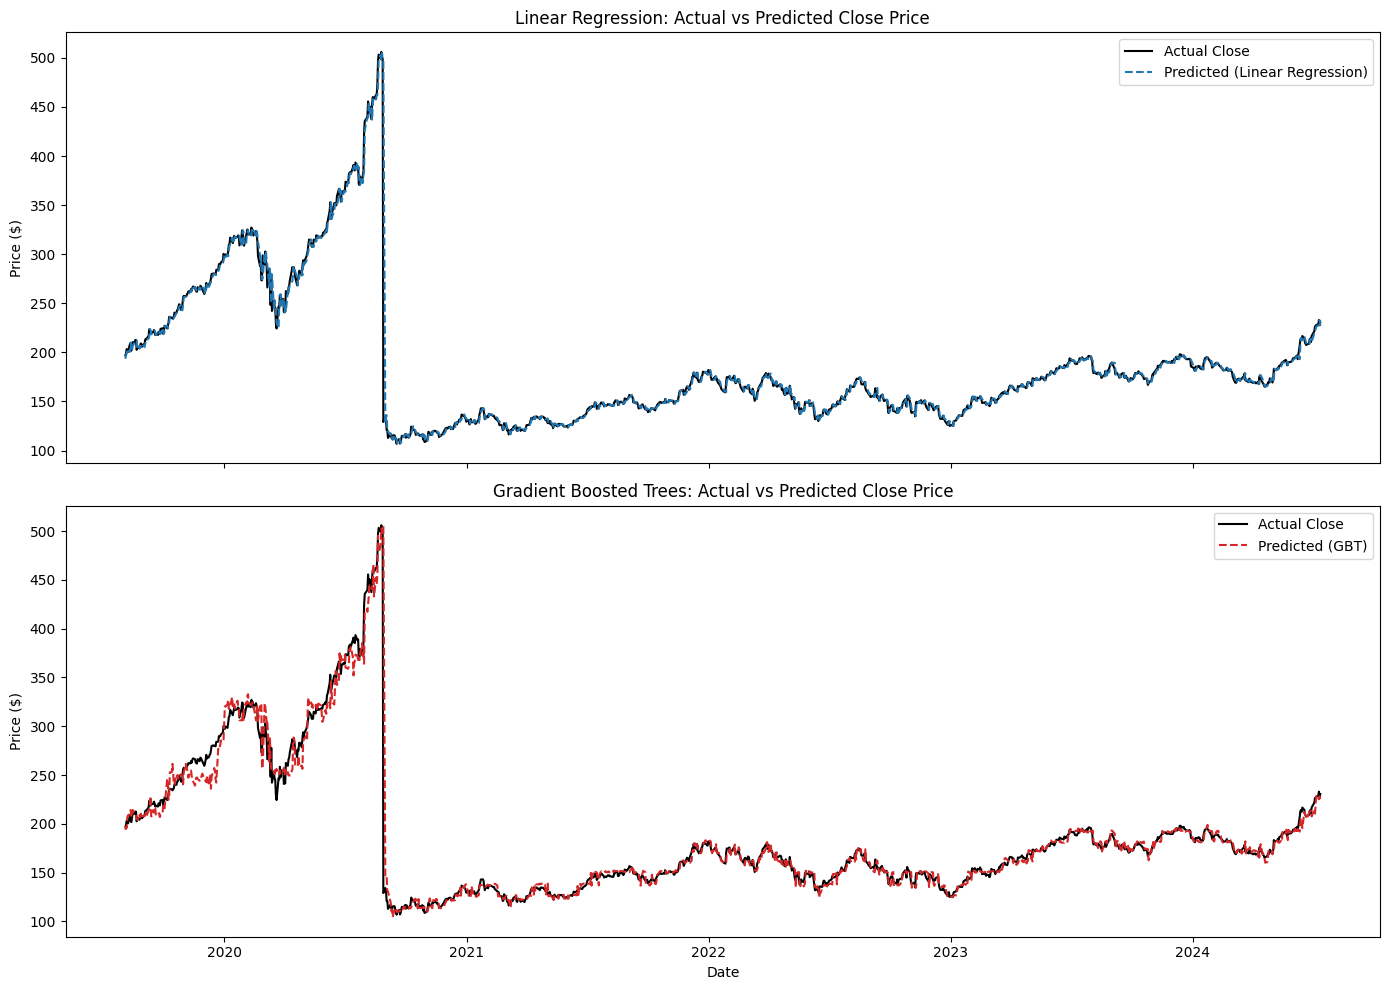

In [12]:
# Convert predictions to pandas for plotting (test set is small enough to collect)
lr_pd = lr_predictions.select("Date", "target", "prediction").orderBy("Date").toPandas()
gbt_pd = gbt_predictions.select("Date", "target", "prediction").orderBy("Date").toPandas()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(lr_pd["Date"], lr_pd["target"], label="Actual Close", color="black", linewidth=1.5)
axes[0].plot(lr_pd["Date"], lr_pd["prediction"], label="Predicted (Linear Regression)", color="tab:blue", linestyle="--")
axes[0].set_title("Linear Regression: Actual vs Predicted Close Price")
axes[0].set_ylabel("Price ($)")
axes[0].legend()

axes[1].plot(gbt_pd["Date"], gbt_pd["target"], label="Actual Close", color="black", linewidth=1.5)
axes[1].plot(gbt_pd["Date"], gbt_pd["prediction"], label="Predicted (GBT)", color="tab:red", linestyle="--")
axes[1].set_title("Gradient Boosted Trees: Actual vs Predicted Close Price")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Price ($)")
axes[1].legend()

plt.tight_layout()
plt.show()
